# Notebook 1: Data Collection

This notebook downloads and processes all data required for the Patagonia windhydro energy drought analysis:

1. ERA5 reanalysis variables (wind, precipitation, runoff, temperature, snowmelt)
2. Climate mode indices (SAM, ONI, IOD)
3. Unit conversions and quality checks
4. Area-averaged timeseries for the study region

**Study Region:** 38°S–47.5°S, 72°W–62°W (Northern Patagonia energy corridor)  
**Period:** 1979–2025  
**Resolution:** 0.25° monthly

## Imports

In [1]:
import os
import calendar
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import cdsapi
import regionmask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import zipfile

warnings.filterwarnings('ignore', category=FutureWarning)

## Defining Constants

In [2]:
# Patagonia region bounding box
NORTH = -38.0
SOUTH = -47.5
WEST = -72.0
EAST = -62.0

# Timeframe
YEAR_START = 1979
YEAR_END = 2025

# filepaths
RAW_DIR = '../data/raw'
PROCESSED_DIR = '../data/processed'
METADATA_DIR = '../data/metadata'


## ERA5 Install

In [3]:
client = cdsapi.Client()

# Define the variables and file I want to install from CDS api
era5_variables = {
    "single_levels": {
        "dataset": "reanalysis-era5-single-levels-monthly-means",
        "product_type": "monthly_averaged_reanalysis",
        "variables": [
            "100m_u_component_of_wind",
            "100m_v_component_of_wind",
            "2m_temperature",
            "total_precipitation",
            "runoff",
            "snowmelt",
        ]
    }
}

years = [str(y) for y in range(YEAR_START, YEAR_END + 1)]
months = [str(m).zfill(2) for m in range(1, 13)]

filepath = os.path.join(RAW_DIR, "era5_monthly_patagonia.nc")

# Install the file from CDS api
if not os.path.exists(filepath):
    client.retrieve(
        era5_variables["single_levels"]["dataset"],
        {
            "product_type": era5_variables["single_levels"]["product_type"],
            "variable": era5_variables["single_levels"]["variables"],
            "year": years,
            "month": months,
            "time": "00:00",
            "area": [NORTH, WEST, SOUTH, EAST],
            "format": "netcdf",
        },
        filepath,
    )
    print(f"Downloaded ERA5 data to {filepath}")
else:
    print(f"ERA5 data already exists at {filepath}")

ERA5 data already exists at ../data/raw\era5_monthly_patagonia.nc


## Unzipping and remerging the CDS install

In [4]:
# Needs to be unzipped as CDS still hasn't fixed them giving you a zipped file of avgad and avgua variables despite requesting a netcdf
if zipfile.is_zipfile(filepath):
    print("Downloaded file is a ZIP archive. extracting...")
    
    with zipfile.ZipFile(filepath, 'r') as z:
        print(f"ZIP contents: {z.namelist()}")
        z.extractall(RAW_DIR)
        
        nc_files = [f for f in z.namelist() if f.endswith(".nc")]
        print(f"Found {len(nc_files)} NetCDF files: {nc_files}")
else:
    nc_filepath = filepath
    print("File is already NetCDF format")

# Open each file and inspect before merging
datasets = {}
for f in nc_files:
    fpath = os.path.join(RAW_DIR, f)
    ds_temp = xr.open_dataset(fpath)

    if "valid_time" in ds_temp.dims:
        ds_temp = ds_temp.rename({"valid_time": "time"})

    ds_temp["time"] = ds_temp.time.values.astype("datetime64[M]").astype("datetime64[ns]")

    print(f"\n{f}:")
    print(f"  Variables: {list(ds_temp.data_vars)}")
    print(f"  Time[0]: {ds_temp.time.values[0]}")
    print(f"  Time[-1]: {ds_temp.time.values[-1]}")
    datasets[f] = ds_temp

# Merge into single dataset
ds = xr.merge(datasets.values())

print(f"\nMerged dataset:")
print(f"  Variables: {list(ds.data_vars)}")
print(f"  Time range: {ds.time.values[0]} to {ds.time.values[-1]}")
print(f"  Latitude range: {ds.latitude.values.min():.2f} to {ds.latitude.values.max():.2f}")
print(f"  Longitude range: {ds.longitude.values.min():.2f} to {ds.longitude.values.max():.2f}")
print(f"  Grid size: {len(ds.latitude)} x {len(ds.longitude)}")

print(f"\nAll variables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims}, units: {ds[var].attrs.get('units', 'unknown')}")

Downloaded file is a ZIP archive. extracting...
ZIP contents: ['data_stream-moda_stepType-avgua.nc', 'data_stream-moda_stepType-avgad.nc']
Found 2 NetCDF files: ['data_stream-moda_stepType-avgua.nc', 'data_stream-moda_stepType-avgad.nc']

data_stream-moda_stepType-avgua.nc:
  Variables: ['u100', 'v100', 't2m']
  Time[0]: 1979-01-01T00:00:00.000000000
  Time[-1]: 2025-12-01T00:00:00.000000000

data_stream-moda_stepType-avgad.nc:
  Variables: ['tp', 'ro', 'smlt']
  Time[0]: 1979-01-01T00:00:00.000000000
  Time[-1]: 2025-12-01T00:00:00.000000000

Merged dataset:
  Variables: ['u100', 'v100', 't2m', 'tp', 'ro', 'smlt']
  Time range: 1979-01-01T00:00:00.000000000 to 2025-12-01T00:00:00.000000000
  Latitude range: -47.50 to -38.00
  Longitude range: -72.00 to -62.00
  Grid size: 39 x 41

All variables:
  u100: ('time', 'latitude', 'longitude'), units: m s**-1
  v100: ('time', 'latitude', 'longitude'), units: m s**-1
  t2m: ('time', 'latitude', 'longitude'), units: K
  tp: ('time', 'latitude'

## Converting the units to correct ones + New Dataset

In [5]:
# Wind speed from u and v components
# wind_speed = sqrt(u^2 + v^2)
wind_speed = np.sqrt(ds["u100"]**2 + ds["v100"]**2)
wind_speed.attrs["units"] = "m/s"
wind_speed.attrs["long_name"] = "100m wind speed"

# Temperature: Kelvin to Celsius
temperature = ds["t2m"] - 273.15
temperature.attrs["units"] = "°C"
temperature.attrs["long_name"] = "2m temperature"

# Precipitation: m/day to mm/month
# ERA5 monthly means give average daily rate in metres
# Multiply by 1000 (m to mm) and by days in each month
days_in_month = ds.time.dt.days_in_month
precipitation = ds["tp"] * 1000 * days_in_month
precipitation.attrs["units"] = "mm/month"
precipitation.attrs["long_name"] = "Total precipitation"

# Runoff: same conversion as precipitation
runoff = ds["ro"] * 1000 * days_in_month
runoff.attrs["units"] = "mm/month"
runoff.attrs["long_name"] = "Total runoff"

# Snowmelt: same conversion as precipitation
snowmelt = ds["smlt"] * 1000 * days_in_month
snowmelt.attrs["units"] = "mm/month"
snowmelt.attrs["long_name"] = "Snowmelt"

# Combine into a clean dataset
ds_converted = xr.Dataset({
    "wind_speed": wind_speed,
    "temperature": temperature,
    "precipitation": precipitation,
    "runoff": runoff,
    "snowmelt": snowmelt,
})

print("Converted dataset:")
print(ds_converted)

Converted dataset:
<xarray.Dataset> Size: 29MB
Dimensions:        (time: 564, latitude: 39, longitude: 41)
Coordinates:
  * time           (time) datetime64[ns] 5kB 1979-01-01 ... 2025-12-01
    expver         (time) <U4 9kB '0001' '0001' '0001' ... '0001' '0001' '0001'
  * latitude       (latitude) float64 312B -38.0 -38.25 -38.5 ... -47.25 -47.5
  * longitude      (longitude) float64 328B -72.0 -71.75 -71.5 ... -62.25 -62.0
    number         int64 8B 0
Data variables:
    wind_speed     (time, latitude, longitude) float32 4MB 3.417 1.317 ... 6.722
    temperature    (time, latitude, longitude) float32 4MB 15.85 15.39 ... 12.13
    precipitation  (time, latitude, longitude) float64 7MB 22.05 32.4 ... 13.45
    runoff         (time, latitude, longitude) float64 7MB 24.83 25.87 ... 0.0
    snowmelt       (time, latitude, longitude) float64 7MB 0.0 0.0 ... 0.0 0.0


## Create land sea mask

Total grid cells: 1599
Land grid cells: 1186
Ocean grid cells: 413
Land fraction: 74.2%


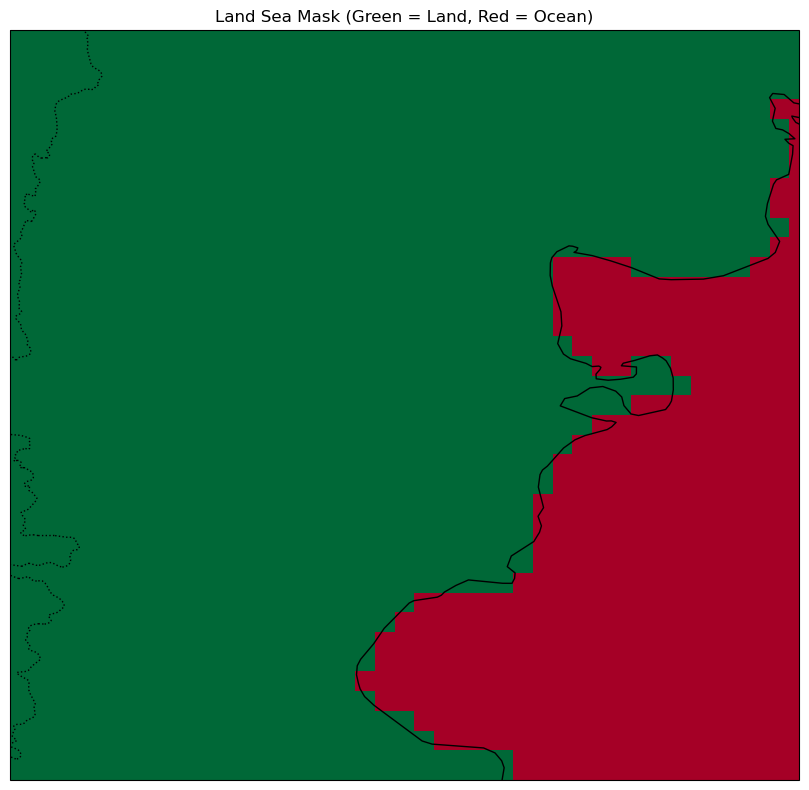

In [6]:
# Creating a land mask with regionmask, its sufficiently accurate to not meaningfully affect the data
# This is to prevent the ocean tiles from contaminating the area averages
land_mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(ds_converted["longitude"], ds_converted["latitude"])

is_land = ~np.isnan(land_mask)

print(f"Total grid cells: {is_land.size}")
print(f"Land grid cells: {is_land.sum().values}")
print(f"Ocean grid cells: {(~is_land).sum().values}")
print(f"Land fraction: {is_land.sum().values / is_land.size:.1%}")

# Visualise the mask to verify it 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
is_land.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap="RdYlGn", 
    add_colorbar=False,
)
ax.coastlines(resolution='50m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title("Land Sea Mask (Green = Land, Red = Ocean)")
ax.set_extent([WEST, EAST, SOUTH, NORTH], crs=ccrs.PlateCarree())

plt.tight_layout()

In [7]:
# Modify the dataset with the mask if it all comes out ok
ds_masked = ds_converted.where(is_land)

## Computer Area Weight Averages

In [8]:
# Grid cells at different latitudes cover different areas a cell at -38°S is physically larger than a cell at -47.5°S so I need to weight by cosine of the latitude
weights = np.cos(np.deg2rad(ds_masked.latitude))
weights.name = "weights"

# Compute weighted mean across lat/lon for each timestep
ds_mean = ds_masked.weighted(weights).mean(dim=["latitude", "longitude"])

# Make it a dataframe and clean it up
df_era5 = ds_mean.to_dataframe().reset_index()
df_era5 = df_era5.rename(columns={"time": "date"})
df_era5 = df_era5.set_index("date")
df_era5 = df_era5[['wind_speed', 'temperature', 'precipitation', 'runoff', 'snowmelt']]

print(df_era5.head(10))
print(f"\nShape: {df_era5.shape}")
print(f"Date range: {df_era5.index[0]} to {df_era5.index[-1]}")

            wind_speed  temperature  precipitation     runoff   snowmelt
date                                                                    
1979-01-01    3.591189    20.300608      33.127508   4.771823   0.007942
1979-02-01    4.052137    19.015506      13.530812   2.303862   0.008822
1979-03-01    2.668088    15.476255      31.482286   2.530781   0.201180
1979-04-01    2.939223    12.290993      11.758993   1.787631   0.171488
1979-05-01    4.399244     7.483713      74.614402  12.958914  18.369194
1979-06-01    5.418746     5.016111      38.053718  14.461718  17.027098
1979-07-01    4.166877     5.541816      67.018221  19.410503  20.859196
1979-08-01    4.802783     6.330473      91.547662  40.708558  37.557451
1979-09-01    4.280102     6.910610      44.095440  21.879376  19.075465
1979-10-01    4.827403    10.290414      52.791928  24.935240  32.357695

Shape: (564, 5)
Date range: 1979-01-01 00:00:00 to 2025-12-01 00:00:00
